## **E-commerce product recommendations using catboost**

**1. Import all the libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

**2. Import the dataset**

In [2]:
df = pd.read_excel('Online-Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


**3. Data Preprocessing**

In [4]:
df.dropna(inplace=True)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Price'] = df['UnitPrice'] * df['Quantity']

df = df[df['Quantity'] > 0]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**4. Feature engineering**: We'll create features like the recency, frequency and monetary value (RFM) for each customer.

In [5]:
refer_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
  'InvoiceDate': lambda x : (refer_date - x.min()).days,
  'InvoiceNo': 'nunique',
  'Price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,367,7,4310.00
12348.0,358,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**5. Train, test split**

In [7]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = np.where(rfm['Monetary'] > rfm['Monetary'].median(), 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.25,
  random_state=42
)

X_train.shape, X_test.shape

((3254, 3), (1085, 3))

**6. Train the cat boost model**

In [8]:
model = CatBoostClassifier(
  iterations=100, learning_rate=0.01, depth=6, verbose=False
)

model.fit(X_train, y_train)
accuracy_score = model.score(X_test, y_test)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.9972350230414746


**7. Visualize performance**

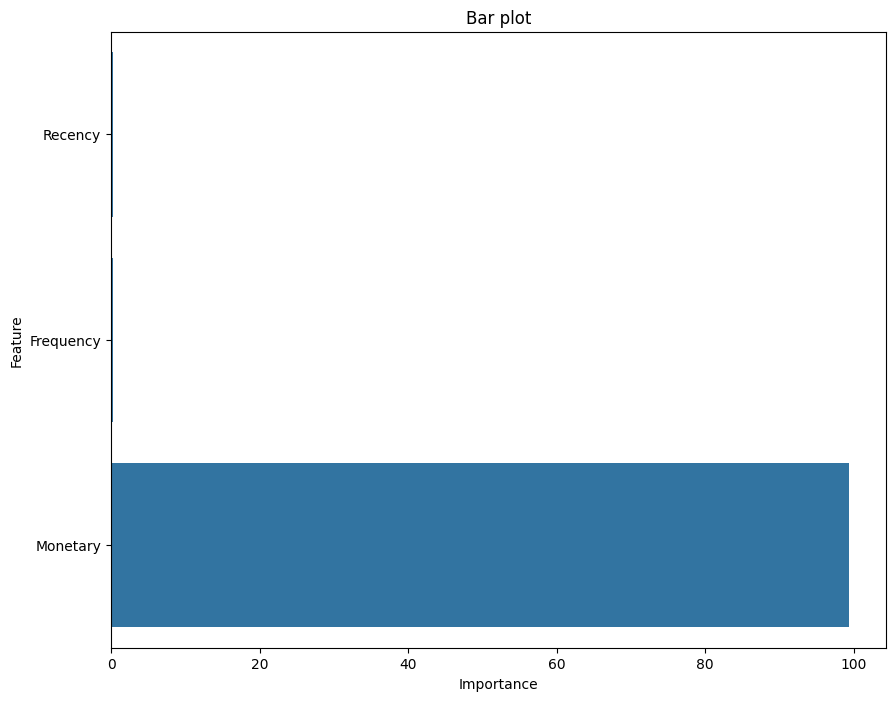

In [9]:
feat_importance = model.get_feature_importance()
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feat_importance})

plt.figure(figsize=(10, 8))
plt.title("Bar plot")
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.show()

**8. Interactive GUI with ipywidgets**: We'll create an interactive GUI where users can input recency, frequency and monetary values to get a recommendation.

In [10]:
import ipywidgets as widgets
from IPython.display import display

recency_input = widgets.IntSlider(min=0, max=365, step=1, description='Recency')
frequency_input = widgets.IntSlider(min=0, max=100, step=1, description='Frequency')
monetary_input = widgets.FloatSlider(min=0, max=10000, step=0.01, description='Monetary')

output = widgets.Output()

def make_prediction(recency, frequency, monetary):
  data = pd.DataFrame({'Recency': [recency], 'Frequency': [frequency], 'Monetary': [monetary]})
  prediction = model.predict(data)[0]
  return "Recommend" if prediction == 1 else "Do not recommend"

def update_prediction(change):
  with output:
    output.clear_output()
    prediction = make_prediction(recency_input.value, frequency_input.value, monetary_input.value)
    print(f'Recommendation: {prediction}')

recency_input.observe(update_prediction, names='value')
frequency_input.observe(update_prediction, names='value')
monetary_input.observe(update_prediction, names='value')

display(recency_input, frequency_input, monetary_input, output)

IntSlider(value=0, description='Recency', max=365)

IntSlider(value=0, description='Frequency')

FloatSlider(value=0.0, description='Monetary', max=10000.0, step=0.01)

Output()